<div style="background: linear-gradient(135deg,#6C63FF,#2E86C1); padding:30px; border-radius:15px; box-shadow:0px 8px 25px rgba(0,0,0,0.15);">

<h1 style="color:white; text-align:center; font-size:38px;">
 🏠 House Prices Regression
</h1>

<p style="color:white; text-align:center; font-size:18px;">
Dataset is crawled from Divar.ir 
</p>

</div>

---

<div style="background-color:#F8F9FA; padding:20px; border-radius:12px; box-shadow:0px 4px 12px rgba(0,0,0,0.08);">

<h2 style="color:#FF6F61;">🔎 Project Overview</h2>

<p style="color:#444; font-size:16px;">
In this project, we built a machine learning pipeline to predict <strong>Tehran house prices</strong> We performed data cleaning and contextual outlier detection, compared different encoding strategies for the `Address` feature, evaluated multiple regression models, and selected the best-performing approach for the final prediction model.
</p>

</div>

---

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  📦 Import Necessary Libraries
</h2>

First import the preliminary modules that will be used in this project:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV

import joblib
import time

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  📥 Load and Prepare Data
</h2>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mokar2001/house-price-tehran-iran")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/house-price-tehran-iran


In [39]:
housePrices = pd.read_csv(f"{path}/housePrice.csv")

housePrices.sample(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
1100,102,2,True,True,True,Southern Janatabad,5.600000e+09,186666.67
1155,62,1,True,True,True,Southern Program Organization,2.170000e+09,72333.33
1780,182,3,True,True,True,Saadat Abad,1.150000e+10,383333.33
2674,119,3,True,True,True,Shahran,5.500000e+09,183333.33
2455,105,2,True,True,True,Kahrizak,1.160000e+09,38666.67
2889,105,2,True,True,True,Persian Gulf Martyrs Lake,2.700000e+09,90000.00
302,60,1,True,True,False,Southern Janatabad,2.280000e+09,76000.00
793,109,3,True,True,True,Feiz Garden,4.230000e+09,141000.00
947,56,1,True,True,True,Feiz Garden,2.000000e+09,66666.67
876,102,2,True,True,True,Gheitarieh,8.100000e+09,270000.00


<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  🧹 Data Cleaning
</h2>

First we have to remove missing values.As we can see, `Address` column has 23 null values.

In [121]:
housePrices.isnull().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [40]:
housePrices.dropna(inplace = True)

Now we have to remove duplicate rows.

In [41]:
housePrices.drop_duplicates(inplace = True)

len(housePrices)

3248

All the independent variables should be numerical, in order to use them for machine learning algorithms. So lets take a look at each column type:

In [109]:
housePrices.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3248 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3248 non-null   object 
 1   Room        3248 non-null   int64  
 2   Parking     3248 non-null   bool   
 3   Warehouse   3248 non-null   bool   
 4   Elevator    3248 non-null   bool   
 5   Address     3248 non-null   object 
 6   Price       3248 non-null   float64
 7   Price(USD)  3248 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 161.8+ KB


In [63]:
housePrices['Area'].unique()

array(['63', '60', '79', '95', '123', '70', '87', '59', '54', '71', '68',
       '64', '136', '155', '140', '42', '93', '65', '99', '105', '160',
       '77', '110', '100', '90', '49', '96', '67', '62', '55', '129',
       '109', '58', '150', '130', '88', '51', '113', '98', '75', '61',
       '72', '122', '215', '101', '53', '74', '114', '151', '300', '76',
       '148', '40', '128', '94', '97', '137', '85', '78', '48', '82',
       '120', '139', '66', '80', '44', '50', '121', '141', '127', '180',
       '158', '144', '245', '190', '108', '117', '200', '125', '236',
       '220', '86', '84', '106', '320', '154', '210', '124', '83', '270',
       '104', '103', '165', '135', '132', '81', '153', '166', '175',
       '170', '115', '118', '116', '43', '230', '91', '126', '450', '500',
       '145', '112', '192', '164', '265', '92', '143', '350', '335',
       '235', '225', '221', '312', '188', '198', '650', '179', '256',
       '257', '167', '246', '168', '280', '69', '400', '660', '213', '

We can see that `Area` column has a string type(object).This should be coverted to int type.It also has characters like ',' that must be cleaned from it. 

In [42]:
housePrices['Area'] = housePrices['Area'].apply(lambda x: x.replace(',', ''))
housePrices['Area'] = housePrices['Area'].astype(int)

It is better to convert boolean features to int type:

In [43]:
boolean_features = ['Parking','Warehouse','Elevator']
housePrices[boolean_features] = housePrices[boolean_features].astype('int64')

In [22]:
print(housePrices.dtypes)

Area            int64
Room            int64
Parking         int64
Warehouse       int64
Elevator        int64
Address        object
Price         float64
Price(USD)    float64
dtype: object


In [10]:
sorted_addresses = sorted(housePrices['Address'].unique())
print(sorted_addresses)

['Abazar', 'Abbasabad', 'Absard', 'Abuzar', 'Afsarieh', 'Ahang', 'Air force', 'Ajudaniye', 'Alborz Complex', 'Aliabad South', 'Amir Bahador', 'Amirabad', 'Amirieh', 'Andisheh', 'Aqdasieh', 'Araj', 'Argentina', 'Atabak', 'Azadshahr', 'Azarbaijan', 'Azari', 'Baghestan', 'Bahar', 'Baqershahr', 'Beryanak', 'Boloorsazi', 'Central Janatabad', 'Chahardangeh', 'Chardangeh', 'Chardivari', 'Chidz', 'Damavand', 'Darabad', 'Darakeh', 'Darband', 'Daryan No', 'Dehkade Olampic', 'Dezashib', 'Dolatabad', 'Dorous', 'East Ferdows Boulevard', 'East Pars', 'Ekbatan', 'Ekhtiarieh', 'Elahieh', 'Elm-o-Sanat', 'Enghelab', 'Eram', 'Eskandari', 'Fallah', 'Farmanieh', 'Fatemi', 'Feiz Garden', 'Firoozkooh', 'Firoozkooh Kuhsar', 'Gandhi', 'Garden of Saba', 'Gheitarieh', 'Ghiyamdasht', 'Ghoba', 'Gholhak', 'Gisha', 'Golestan', 'Haft Tir', 'Hakimiyeh', 'Hashemi', 'Hassan Abad', 'Hekmat', 'Heravi', 'Heshmatieh', 'Hor Square', 'Islamshahr', 'Islamshahr Elahieh', 'Javadiyeh', 'Jeyhoon', 'Jordan', 'Kahrizak', 'Kamranieh'

In [11]:
housePrices['Address'].nunique()

192

The data contains inconsistent address labels. Some categories are different spellings of the same location—for example, `Vahidiyeh` and `Vahidieh`. Others, such as `Mehrabad River River` and `Chidz`, appear to be misspelled and need correction.

In [44]:
housePrices['Address'] = housePrices['Address'].replace({
    #different spellings
    'Shahrake Quds': 'Shahrake Qods',
    'Vahidieh': 'Vahidiyeh',
    'Chardangeh': 'Chahardangeh',
    #wrong spellings
    'Mehrabad River River': 'Mehrabad River',
    'Northren Jamalzadeh': 'Northern Jamalzadeh',
    'North Program Organization': 'Northern Program Organization',
    'Dorous': 'Darrous',
    'Air force': 'Air Force',
    'Chidz': 'Chizar',
})

In [11]:
sorted_addresses = sorted(housePrices['Address'].unique())
print(sorted_addresses)

['Abazar', 'Abbasabad', 'Absard', 'Abuzar', 'Afsarieh', 'Ahang', 'Air Force', 'Ajudaniye', 'Alborz Complex', 'Aliabad South', 'Amir Bahador', 'Amirabad', 'Amirieh', 'Andisheh', 'Aqdasieh', 'Araj', 'Argentina', 'Atabak', 'Azadshahr', 'Azarbaijan', 'Azari', 'Baghestan', 'Bahar', 'Baqershahr', 'Beryanak', 'Boloorsazi', 'Central Janatabad', 'Chahardangeh', 'Chardivari', 'Chizar', 'Damavand', 'Darabad', 'Darakeh', 'Darband', 'Darrous', 'Daryan No', 'Dehkade Olampic', 'Dezashib', 'Dolatabad', 'East Ferdows Boulevard', 'East Pars', 'Ekbatan', 'Ekhtiarieh', 'Elahieh', 'Elm-o-Sanat', 'Enghelab', 'Eram', 'Eskandari', 'Fallah', 'Farmanieh', 'Fatemi', 'Feiz Garden', 'Firoozkooh', 'Firoozkooh Kuhsar', 'Gandhi', 'Garden of Saba', 'Gheitarieh', 'Ghiyamdasht', 'Ghoba', 'Gholhak', 'Gisha', 'Golestan', 'Haft Tir', 'Hakimiyeh', 'Hashemi', 'Hassan Abad', 'Hekmat', 'Heravi', 'Heshmatieh', 'Hor Square', 'Islamshahr', 'Islamshahr Elahieh', 'Javadiyeh', 'Jeyhoon', 'Jordan', 'Kahrizak', 'Kamranieh', 'Karimkhan

In [45]:
housePrices['Address'].nunique()

189

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  🔎 Exploratory Data Analysis (EDA)
</h2>

In [129]:
housePrices.describe()

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD)
count,3.248000e+03,3248.000000,3248.000000,3248.000000,3248.000000,3.248000e+03,3.248000e+03
mean,9.365872e+06,2.088054,0.845135,0.914101,0.785406,5.478118e+09,1.826039e+05
std,3.277906e+08,0.764716,0.361831,0.280258,0.410603,8.267916e+09,2.755972e+05
min,3.000000e+01,0.000000,0.000000,0.000000,0.000000,3.600000e+06,1.200000e+02
25%,7.000000e+01,2.000000,1.000000,1.000000,1.000000,1.420000e+09,4.733333e+04
50%,9.000000e+01,2.000000,1.000000,1.000000,1.000000,2.977500e+09,9.925000e+04
75%,1.220000e+02,2.000000,1.000000,1.000000,1.000000,6.200000e+09,2.066667e+05
max,1.616000e+10,5.000000,1.000000,1.000000,1.000000,9.240000e+10,3.080000e+06


In [16]:
housePrices['Address'].value_counts().rename_axis('Address').reset_index(name='Count')

,Address,Count
0,Punak,148
1,West Ferdows Boulevard,133
2,Gheitarieh,133
3,Shahran,123
4,Pardis,123
...,...,...
184,Bahar,1
185,Azari,1
186,Baqershahr,1
187,Ray - Pilgosh,1


### Mean Price per Address

In [17]:
mean_price_per_address  = (
    housePrices.groupby('Address')['Price']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'Mean Price', 'count': 'Count'})
    .rename_axis('Address')
    .reset_index()
)
mean_price_per_address 

,Address,Mean Price,Count
0,Gandhi,7.000000e+10,1
1,Lavasan,4.800000e+10,4
2,Mahmoudieh,3.346667e+10,3
3,Vanak,3.270000e+10,2
4,Elahieh,2.678635e+10,17
...,...,...,...
184,Hassan Abad,5.100000e+08,1
185,Firoozkooh,4.700000e+08,1
186,Pishva,3.400000e+08,2
187,Robat Karim,3.275000e+08,2


Looking at the raw groupby result without any filtering, ‍‍‍`Gandhi‍‍‍‍‍` appears as the
most expensive address and `Malard` as the cheapest — but both are based on only
a single listing, so their means are not reliable. To get a more reliable
picture, we filter to addresses with at least 10 listings:

In [18]:
mean_price_per_address[mean_price_per_address['Count'] >= 10]

,Address,Mean Price,Count
4,Elahieh,2.678635e+10,17
6,Zaferanieh,2.357515e+10,27
7,Velenjak,2.138136e+10,22
8,Farmanieh,2.066580e+10,56
9,Niavaran,1.986027e+10,67
...,...,...,...
155,Kahrizak,1.071567e+09,15
163,Shahrake Qods,8.922338e+08,71
165,Pakdasht,8.502083e+08,24
173,Pardis,7.937154e+08,123


Filtering to addresses with at least 10 houses gives a much cleaner picture:
`Elahieh`, `Zaferanieh`, `Velenjak`, `Farmanieh`, and `Niavaran` stand out as the most
expensive areas (northern Tehran), while `Parand`, `Pardis`, `Pakdasht`, `Shahrake
Qods`, and `Kahrizak` are the cheapest (peripheral and southern districts). This
filtered ranking will guide our address encoding later.

### Mean Price by Number of Rooms

In [19]:
housePrices.groupby( 'Room' )['Price'].mean()

Room
0    8.715556e+09
1    1.717832e+09
2    3.363038e+09
3    1.104311e+10
4    2.568122e+10
5    3.373439e+10
Name: Price, dtype: float64

In [46]:
housePrices['Price_per_sqm'] = housePrices['Price'] / housePrices['Area']
housePrices.groupby('Room')['Price_per_sqm'].median()

Room
0    8.372093e+06
1    2.567568e+07
2    3.301887e+07
3    6.094812e+07
4    8.737288e+07
5    8.333333e+07
Name: Price_per_sqm, dtype: float64

In [14]:
housePrices[housePrices['Room'] == 0]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price_per_sqm
103,40,0,0,0,0,Shahrake Qods,2.480000e+08,8266.67,6.200000e+06
137,40,0,0,0,0,Pakdasht,1.650000e+08,5500.00,4.125000e+06
1169,40,0,0,1,0,Ostad Moein,6.500000e+08,21666.67,1.625000e+07
2103,43,0,0,1,0,Nasim Shahr,3.600000e+08,12000.00,8.372093e+06
2625,50,0,1,1,1,Northern Chitgar,3.450000e+08,11500.00,6.900000e+06
2721,110,0,1,1,1,Parand,1.020000e+08,3400.00,9.272727e+05
3107,630,0,0,0,0,Tajrish,7.560000e+10,2520000.00,1.200000e+08
3211,30,0,0,1,0,Ostad Moein,5.000000e+08,16666.67,1.666667e+07
3435,54,0,0,0,0,Shahrake Qods,4.700000e+08,15666.67,8.703704e+06


In [15]:
print((housePrices['Room'] == 0).sum() / len(housePrices) * 100, '%')

0.2770935960591133 %


Excluding `Room = 0`, mean price increases monotonically with room count, from
~1.7B for one-room units to ~33.7B for five-room units.

`Room = 0` accounts for only 0.28% of the data (9 listings). Inspecting these
rows shows that 6 of them have areas between 30 and 54 sqm — consistent with
**studio** apartments. The two exceptions are a 110 sqm unit in Parand and a 630
sqm luxury property in Tajrish, the latter being a clear outlier that inflates
the group's mean area from ~51 sqm to ~115 sqm and its mean price per sqm from
~8.4M to ~20.9M.

Because of this outlier, summary statistics for `Room = 0` are misleading. A
more careful look suggests that most `Room = 0` listings are likely **studios**,
with a single large luxury property inflating the group.

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  📈Data Visualization📊
</h2>

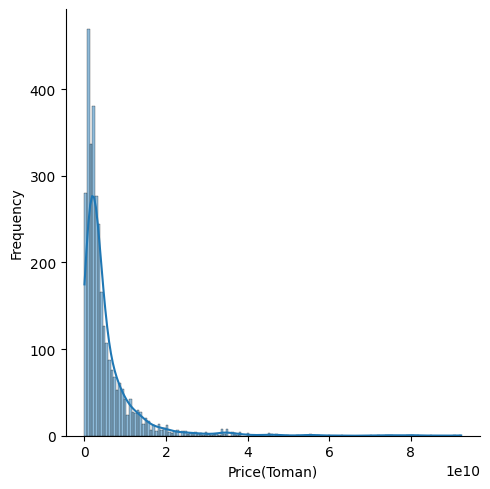

In [12]:
sns.displot(data= housePrices, x="Price", kde = True);

plt.xlabel("Price(Toman)")
plt.ylabel("Frequency")
plt.show()

The price distribution is highly right-skewed. The vast majority of listings
are concentrated below ~20B Tooman, with a sharp peak near 1–2B. A long tail
extends to the right, up to 80B+ Tooman, representing a small number of luxury
properties. This confirms the presence of extreme outliers (such as the 75B
property in Tajrish we identified earlier).

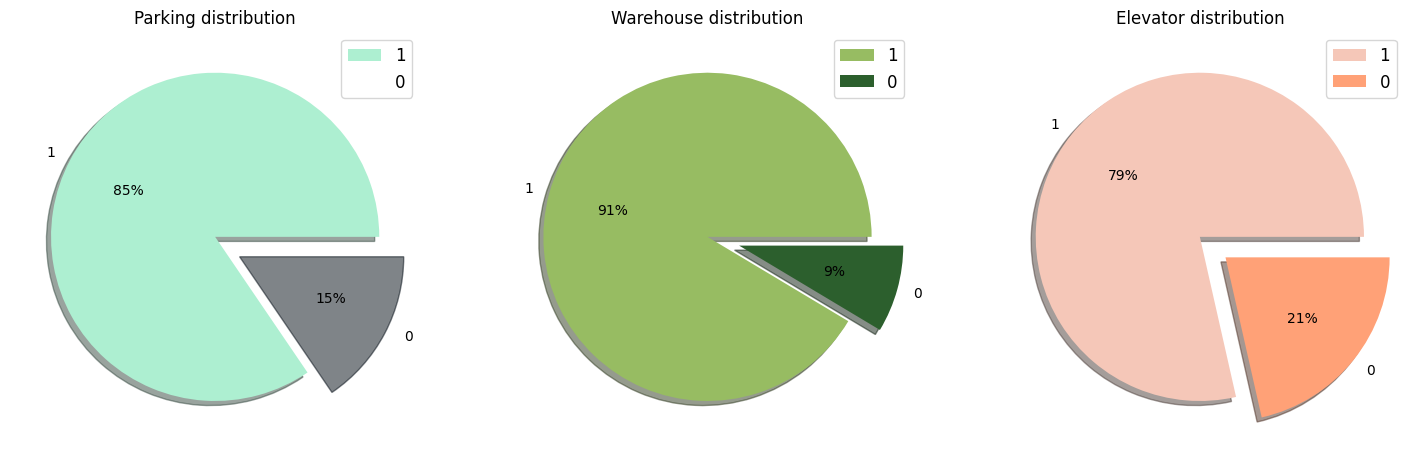

In [52]:
fig, ax = plt.subplots(ncols=3, figsize=(18,6))

colors = [['#ADEFD1FF', '#00203F00'], ['#97BC62FF', '#2C5F2D'], ['#F5C7B8FF', '#FFA177FF']]
explode = [0, 0.2]
columns = ['Parking', 'Warehouse', 'Elevator']
for i in range(3):
        data = housePrices[columns[i]].value_counts()
        ax[i].pie(data, labels=data.index, autopct='%.0f%%', explode=explode, colors=colors[i], shadow=True)
        ax[i].legend(labels=data.index, fontsize='large')
        ax[i].set_title('{} distribution'.format(columns[i]))

Among the listed properties, 85% have parking, 91% have a storage room, and 79% have an elevator.

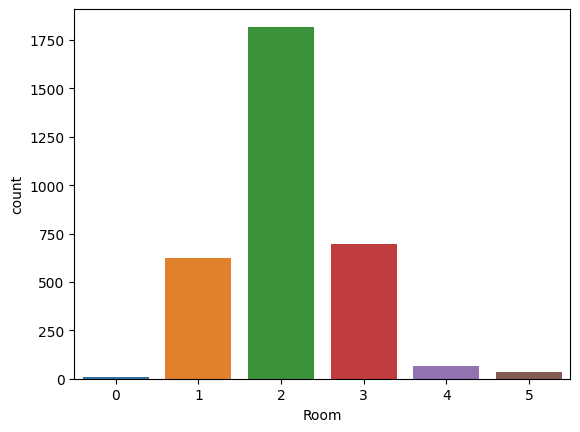

In [112]:
sns.countplot(x='Room', data=housePrices)

plt.show()

2-room units are the most common, followed by 1-room and 3-room units.

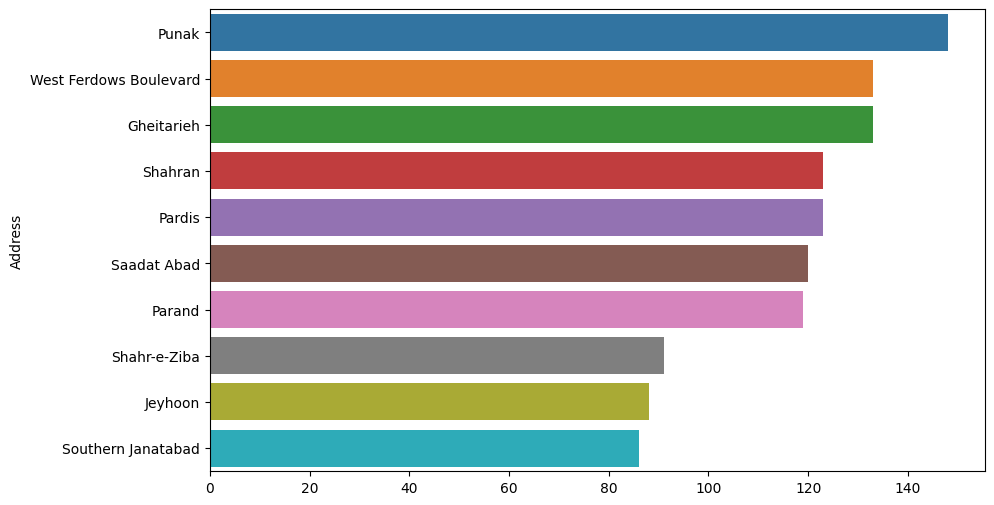

In [113]:
data = housePrices['Address'].value_counts().head(10) 

plt.figure(figsize=(10,6))

sns.barplot(x=data.values, y=data.index)

plt.show()

This chart shows the top 10 most frequent addresses in the dataset. Punak, West Ferdows Boulevard, and Gheitarieh are the most common, each with over 120 listings, followed closely by Shahran, Pardis, Saadat Abad, and Parand (around 120 each). 

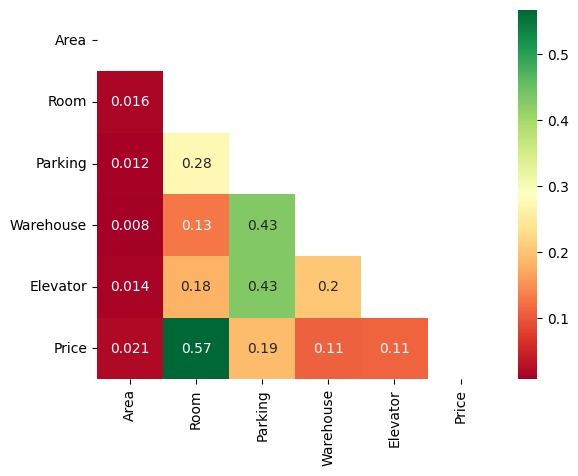

In [22]:
numeric_df = housePrices[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price']]

matrix = np.triu(numeric_df.corr())
sns.heatmap(numeric_df.corr().round(3), mask=matrix, annot=True, cmap='RdYlGn')

plt.show()

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  ✂️Outlier Detection & Removal
</h2>

Now We plot the boxplot for `Area` and `Price` variable:

<Axes: xlabel='Price'>

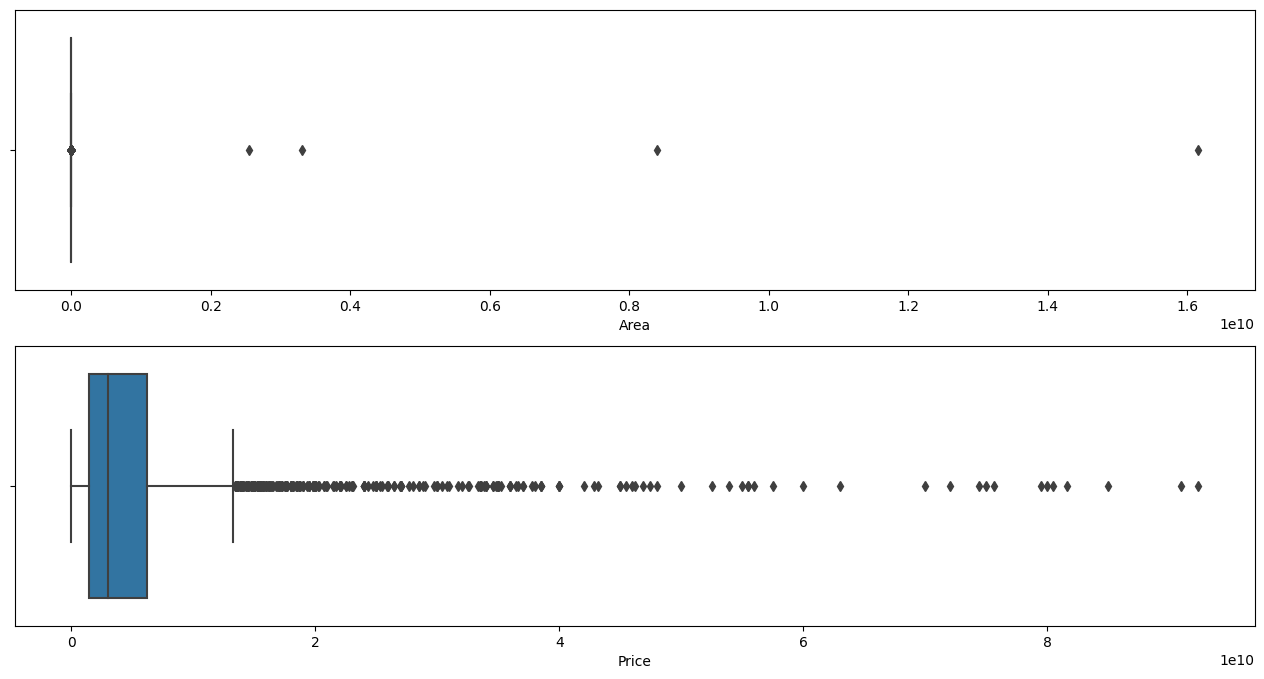

In [10]:
plt.figure(figsize = (16,8))

plt.subplot(2,1,1)
sns.boxplot(x = housePrices['Area'])

plt.subplot(2,1,2)
sns.boxplot(x = housePrices['Price'])

The boxplots reveal severe right-skewness in both variables. For `Area`, the
interquartile range is compressed near zero while a handful of extreme values
extend up to ~1.6 × 10¹⁰ sqm — clearly impossible for a residential property
and almost certainly data-entry errors. For `Price`, the IQR covers a narrow
low range, with a long chain of outliers extending to ~1.6 × 10¹⁰ Tooman.

This confirms that both features require outlier treatment before modeling.

### Outlier Detection Strategy

A common approach to detecting outliers is the **Interquartile Range (IQR) method**. In this approach, values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are considered outliers.

In [77]:
def lower_upper(x):
    Q1 = np.percentile(x, 25)
    Q3 = np.percentile(x, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return lower, upper

lower_area, upper_area = lower_upper(housePrices['Area'])
lower_price, upper_price = lower_upper(housePrices['Price'])

print(f"Lower limit for area: {lower_area:0.2f}")
print(f"Upper limit for area: {upper_area:0.2f}")
print(f"Lower limit for price: {lower_price:,}")
print(f"Upper limit for price: {upper_price:,}")

Lower limit for area: -8.00
Upper limit for area: 200.00
Lower limit for price: -5,750,000,000.0
Upper limit for price: 13,370,000,000.0


In [78]:
area_outliers = np.where(housePrices['Area'] > upper_area)
price_outliers = np.where(housePrices['Price'] > upper_price)
# Return the unique, sorted array of values that are in either of the two input arrays.
total_outliers = np.union1d(area_outliers, price_outliers)

print(f"Number of area outliers: {len(housePrices.iloc[area_outliers])}")
print(f"Number of price outliers: {len(housePrices.iloc[price_outliers])}")
print(f"Number of outliers: {len(housePrices.iloc[total_outliers])}")

Number of area outliers: 192
Number of price outliers: 272
Number of outliers: 319


In our dataset, applying this method globally to `Area` and `Price` identifies **319 out of 3,248 observations** as outliers. However, Tehran's housing market is highly heterogeneous and naturally right-skewed. Property prices and sizes can vary substantially depending on the neighborhood, property type, and location. Therefore, a high price or large area does not necessarily indicate an incorrect observation.

Instead of automatically removing all statistical outliers, we use a **context-aware outlier detection strategy**. We examine extreme observations using `Price_per_sqm` and compare each property with other properties in the same `Address`. Robust statistics such as the **median, quartiles, and IQR within each neighborhood** are used to identify observations that are not only statistically extreme, but also potentially inconsistent with the local distribution.

This approach allows us to distinguish between **legitimate extreme properties** and **likely data errors**, removing only observations for which there is sufficient evidence of incorrect or implausible data.


### Inspecting Extremely Low Price per Square Meter

We first inspect the observations with the lowest `Price_per_sqm` values to identify potential data errors.

In [59]:
housePrices.nsmallest(
    20,
    "Price_per_sqm"
)[["Address", "Area", "Price", "Price_per_sqm"]]

,Address,Area,Price,Price_per_sqm
570,Ostad Moein,3310000000,3.310000e+09,1.000000e+00
709,Pasdaran,16160000000,1.616000e+10,1.000000e+00
2802,Central Janatabad,2550000000,2.550000e+09,1.000000e+00
1604,Gheitarieh,8400000000,8.700000e+09,1.035714e+00
136,Qarchak,160,3.600000e+06,2.250000e+04
2770,Ozgol,83,5.500000e+07,6.626506e+05
731,Pardis,75,6.000000e+07,8.000000e+05
2721,Parand,110,1.020000e+08,9.272727e+05
2201,Andisheh,49,1.100000e+08,2.244898e+06
3300,Persian Gulf Martyrs Lake,120,2.950000e+08,2.458333e+06


In [13]:
housePrices[housePrices['Address'] == "Qarchak"]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Price_per_sqm
128,100,2,1,1,0,Qarchak,1.200000e+09,40000.00,1.200000e+07
136,160,1,0,0,0,Qarchak,3.600000e+06,120.00,2.250000e+04
2189,50,1,0,0,1,Qarchak,3.800000e+08,12666.67,7.600000e+06
2786,95,2,1,1,1,Qarchak,1.450000e+09,48333.33,1.526316e+07
3060,66,1,0,1,0,Qarchak,6.000000e+08,20000.00,9.090909e+06


The first four observations (indices **570, 709, 2802, and 1604**) are clearly problematic. Their `Area` values are extremely large while their `Price` values are almost identical to their `Area`, resulting in an implausible price of approximately **1 Toman per square meter**. These observations are strong candidates for removal.

Observation **136** is also highly suspicious. A 160 m² property with a total price of only 3.6 million Toman results in a `Price_per_sqm` of approximately **22,500 Toman**, which is extremely low compared with the rest of the dataset. This observation is therefore also considered a candidate for removal.

Observation **2171**, located in **Shahryar**, is another candidate that requires further investigation. Its `Area` is **3,600 m²**, which is unusually large, while its `Price_per_sqm` is only **2.7 million Toman**. Unlike the first observations, however, this value cannot be classified as an error based on this inspection alone.

The remaining observations have relatively low `Price_per_sqm` values, but low prices alone are not sufficient to classify them as errors because housing prices can vary substantially across different areas.

At this stage, these observations are treated as **outlier candidates rather than automatically removed**. We will use neighborhood-level statistics and domain-based analysis in the following steps to make the final removal decisions.


### Inspecting Extremely High Price per Square Meter

We also inspect the observations with the highest `Price_per_sqm` values to identify potential high-end outliers.

In [13]:
housePrices.nlargest(
    20,
    "Price_per_sqm"
)[["Address", "Area", "Price", "Price_per_sqm"]]

,Address,Area,Price,Price_per_sqm
3394,West Ferdows Boulevard,54,2.250000e+10,4.166667e+08
3132,Shahr-e-Ziba,60,1.800000e+10,3.000000e+08
2394,Aqdasieh,310,7.440000e+10,2.400000e+08
1332,Niavaran,350,8.050000e+10,2.300000e+08
1707,Zaferanieh,420,9.240000e+10,2.200000e+08
430,Lavasan,400,8.500000e+10,2.125000e+08
2194,Niavaran,350,7.200000e+10,2.057143e+08
1635,Vanak,287,5.750000e+10,2.003484e+08
3420,Si Metri Ji,45,8.900000e+09,1.977778e+08
1565,Velenjak,238,4.690000e+10,1.970588e+08


Several observations have very high prices per square meter, but many are located in expensive neighborhoods such as **Aqdasieh, Niavaran, Zaferanieh, Velenjak, Farmanieh, and Kamranieh**. Their `Area` and `Price` values are also internally consistent, so a high `Price_per_sqm` alone is not sufficient evidence of a data error.

However, some observations require further investigation. In particular, observations **3394** (West Ferdows Boulevard, 416.7M/m²) and **3132** (Shahr-e-Ziba, 300M/m²) stand out from the rest of the data. Their unusually high `Price_per_sqm` values may indicate potential data errors, especially when compared with other properties in the same neighborhood.

Therefore, these observations are treated as **outlier candidates** rather than being removed automatically. Their local neighborhood distributions will be examined in the following steps.


### Inspecting Extremely Large Houses

We next examine the observations with the largest `Area` values.

In [12]:
housePrices[
    housePrices["Area"] > 500
][["Address", "Area", "Price", "Price_per_sqm"]].sort_values(
    "Area",
    ascending=False
)

,Address,Area,Price,Price_per_sqm
709,Pasdaran,16160000000,1.616000e+10,1.000000e+00
1604,Gheitarieh,8400000000,8.700000e+09,1.035714e+00
570,Ostad Moein,3310000000,3.310000e+09,1.000000e+00
2802,Central Janatabad,2550000000,2.550000e+09,1.000000e+00
2171,Shahryar,3600,9.720000e+09,2.700000e+06
807,Damavand,1000,7.000000e+09,7.000000e+06
1694,Zafar,929,8.000000e+10,8.611410e+07
1974,Damavand,900,8.500000e+09,9.444444e+06
573,Gheitarieh,863,7.830000e+09,9.073001e+06
3115,Varamin - Beheshti,750,3.500000e+09,4.666667e+06


The first four observations (**570, 709, 2802, and 1604**) are immediately suspicious because their extremely large `Area` values are accompanied by `Price_per_sqm` values close to **1 Toman**, indicating clear data inconsistencies.

Observation **2171** (Shahryar, 3,600 m²) is also a notable candidate because its area is substantially larger than that of most houses in the dataset. However, its total `Price` and `Price_per_sqm` are internally consistent, so its unusually large area alone does not prove that the observation is incorrect.

The other large houses, such as those in **Damavand, Zafar, Gheitarieh, and Mahmoudieh**, have substantially more plausible price-per-square-meter values and may represent legitimate large houses.

Therefore, this inspection helps us identify potential outliers, while the final decisions will be based on additional contextual and neighborhood-level analysis rather than size alone.

### Neighborhood-Level Robust Statistics

Since housing prices can vary substantially between different areas of Tehran, global statistics may not be appropriate for evaluating individual houses. We therefore calculate robust statistics for `Price_per_sqm` separately for each `Address`.

For each neighborhood, we calculate the **median, Q1, Q3, and IQR**. These statistics provide a more meaningful reference for determining whether a house is unusually expensive or inexpensive relative to other houses in the same area.

In [14]:
# Calculate robust statistics for Price_per_sqm within each Address

address_stats = (
    housePrices
    .groupby("Address")["Price_per_sqm"]
    .agg(
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
)

address_stats["IQR"] = address_stats["Q3"] - address_stats["Q1"]

address_stats.loc[["Shahr-e-Ziba", "Shahryar"]]

,Median,Q1,Q3,IQR
Address,,,,
Shahr-e-Ziba,3.361702e+07,3.109140e+07,3.787500e+07,6.783602e+06
Shahryar,1.062500e+07,1.000000e+07,1.295455e+07,2.954545e+06


In [16]:
# Compare the two suspicious observations with their Address-level statistics

check = housePrices.loc[
    [3132, 2171],
    ["Address", "Area", "Price", "Price_per_sqm"]
].copy()

check = check.join(
    address_stats,
    on="Address"
)

check["Upper_Bound"] = check["Q3"] + 1.5 * check["IQR"]
check["Lower_Bound"] = check["Q1"] - 1.5 * check["IQR"]

check["Ratio_to_Median"] = (
    check["Price_per_sqm"] / check["Median"]
)

check["Robust_Z"] = (check["Price_per_sqm"] - check["Median"]) / check["IQR"]

check

,Address,Area,Price,Price_per_sqm,Median,Q1,Q3,IQR,Upper_Bound,Lower_Bound,Ratio_to_Median,Robust_Z
3132,Shahr-e-Ziba,60,1.800000e+10,300000000.0,3.361702e+07,3.109140e+07,3.787500e+07,6.783602e+06,4.805040e+07,2.091599e+07,8.924051,39.268662
2171,Shahryar,3600,9.720000e+09,2700000.0,1.062500e+07,1.000000e+07,1.295455e+07,2.954545e+06,1.738636e+07,5.568182e+06,0.254118,-2.682308


We now examine two observations that were identified as **potential outliers in `Price_per_sqm`** and compare them with the distribution of houses in their respective neighborhoods.

For **observation 3132 in Shahr-e-Ziba**, the price per square meter is **300 million Toman**, while the neighborhood median is approximately **33.6 million Toman**. This value is about **8.9 times the neighborhood median** and is far above the upper IQR bound of approximately **48.1 million Toman**. Its robust Z-score is approximately **39.3**, indicating an extremely strong deviation from the local distribution. Based on this evidence, observation 3132 is considered a strong candidate for removal.

For **observation 2171 in Shahryar**, the price per square meter is **2.7 million Toman**, compared with a neighborhood median of approximately **10.6 million Toman**. It is below the lower IQR bound of approximately **5.6 million Toman**, making it a statistical outlier within Shahryar. However, its `Area` of **3,600 m²**, total `Price` of **9.72 billion Toman**, and `Price_per_sqm` of **2.7 million Toman** are internally consistent. Therefore, its statistical outlier status alone is not sufficient evidence to classify it as a data error, and the observation will be **kept**.

This analysis highlights an important distinction between a **statistical outlier** and a **data error**. An observation can be an outlier relative to its local distribution without necessarily being incorrect.


### Find and Evaluating Potential Outliers

In [16]:
# Calculate neighborhood-level robust statistics
address_stats = (
    housePrices
    .groupby("Address")["Price_per_sqm"]
    .agg(
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Count="count"
    )
)

address_stats["IQR"] = address_stats["Q3"] - address_stats["Q1"]

# Merge neighborhood statistics back into the original dataset
outlier_check = housePrices[
    ["Address", "Area", "Price", "Price_per_sqm"]
].join(
    address_stats,
    on="Address"
)

# Calculate neighborhood-specific IQR bounds
outlier_check["Upper_Bound"] = (
    outlier_check["Q3"] + 1.5 * outlier_check["IQR"]
)

outlier_check["Lower_Bound"] = (
    outlier_check["Q1"] - 1.5 * outlier_check["IQR"]
)

# Measure how far each observation is from its neighborhood median
outlier_check["Ratio_to_Median"] = (
    outlier_check["Price_per_sqm"] /
    outlier_check["Median"]
)

outlier_check["Robust_Z"] = (
    (outlier_check["Price_per_sqm"] - outlier_check["Median"]) /
    outlier_check["IQR"]
)

# Identify observations outside their neighborhood IQR bounds
local_outliers = outlier_check[
    (outlier_check["Price_per_sqm"] > outlier_check["Upper_Bound"]) |
    (outlier_check["Price_per_sqm"] < outlier_check["Lower_Bound"])
].copy()

# Sort by the absolute magnitude of the robust deviation
local_outliers["Abs_Robust_Z"] = local_outliers["Robust_Z"].abs()

strong_local_outliers = local_outliers[
    (local_outliers["Count"] >= 5) &
    (
        (local_outliers["Ratio_to_Median"] >= 3) |
        (local_outliers["Ratio_to_Median"] <= 1/3)
    )
].copy()

strong_local_outliers["Abs_Robust_Z"] = (
    strong_local_outliers["Robust_Z"].abs()
)

strong_local_outliers.sort_values(
    "Abs_Robust_Z",
    ascending=False
)[[
    "Address",
    "Area",
    "Price",
    "Price_per_sqm",
    "Count",
    "Median",
    "Lower_Bound",
    "Upper_Bound",
    "Ratio_to_Median",
    "Robust_Z"
]]

,Address,Area,Price,Price_per_sqm,Count,Median,Lower_Bound,Upper_Bound,Ratio_to_Median,Robust_Z
3420,Si Metri Ji,45,8.900000e+09,1.977778e+08,21,1.836735e+07,1.393798e+07,2.328165e+07,1.076790e+01,76.805129
3394,West Ferdows Boulevard,54,2.250000e+10,4.166667e+08,133,3.602941e+07,1.833955e+07,5.699627e+07,1.156463e+01,39.386403
3132,Shahr-e-Ziba,60,1.800000e+10,3.000000e+08,91,3.361702e+07,2.091599e+07,4.805040e+07,8.924051e+00,39.268662
2533,Razi,72,4.110000e+08,5.708333e+06,7,1.737500e+07,1.492480e+07,1.992443e+07,3.285372e-01,-9.334026
2532,Narmak,210,2.300000e+10,1.095238e+08,25,3.559322e+07,1.814433e+07,5.509278e+07,3.077098e+00,8.003646
2314,Shahryar,220,7.500000e+09,3.409091e+07,13,1.062500e+07,5.568182e+06,1.738636e+07,3.208556e+00,7.942308
2689,Northern Program Organization,253,3.036000e+10,1.200000e+08,27,3.906667e+07,1.675897e+07,6.608461e+07,3.071672e+00,6.563187
2331,Golestan,300,2.400000e+10,8.000000e+07,15,1.200000e+07,-7.426169e+06,3.637695e+07,6.666667e+00,6.209604
2332,Pardis,100,2.700000e+09,2.700000e+07,123,7.547170e+06,7.625348e+05,1.407448e+07,3.577500e+00,5.845224
2802,Central Janatabad,2550000000,2.550000e+09,1.000000e+00,84,4.072169e+07,2.643295e+07,5.487777e+07,2.455694e-08,-5.726412


In [17]:
address = "Si Metri Ji"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2252,10833333.33
3128,16200000.00
2211,16941176.47
3037,17307692.31
2964,17368421.05
2381,17441860.47
2883,17596153.85
2582,17625000.00
2937,17721518.99
3042,17763157.89


In [18]:
housePrices[
    housePrices["Address"] == "Si Metri Ji"
]["Price_per_sqm"].describe()

count    2.100000e+01
mean     2.725563e+07
std      3.919556e+07
min      1.083333e+07
25%      1.744186e+07
50%      1.836735e+07
75%      1.977778e+07
max      1.977778e+08
Name: Price_per_sqm, dtype: float64

### Si Metri Ji — Outlier Decision

Observation **3420** is clearly isolated from the rest of the houses in Si Metri Ji. Its `Price_per_sqm` is approximately **197.8 million**, while the other houses range from about **10.8 to 27.8 million**. This extreme gap strongly suggests a data anomaly. **Therefore, observation 3420 will be removed.**

In [50]:
address = "West Ferdows Boulevard"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2752,45909090.91
403,46122448.98
1835,47500000.00
1817,47692307.69
1908,48000000.00
1815,50877192.98
1240,52000000.00
1800,52142857.14
540,52500000.00
3468,55000000.00


In [53]:
housePrices[
    housePrices["Address"] == "West Ferdows Boulevard"
]["Price_per_sqm"].describe()

count    1.330000e+02
mean     4.061572e+07
std      3.360944e+07
min      2.520548e+07
25%      3.283582e+07
50%      3.602941e+07
75%      4.250000e+07
max      4.166667e+08
Name: Price_per_sqm, dtype: float64

### West Ferdows Boulevard — Outlier Decision

Observation **3394** is an extreme high-end outlier in West Ferdows Boulevard. Its `Price_per_sqm` is approximately **416.7 million**, far above the neighborhood distribution, where most houses are between roughly **25 and 60 million**. The observation is highly isolated from the rest of the data. **Therefore, observation 3394 will be removed.**


In [47]:
address = "Razi"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2533,5708333.33
2505,16750000.00
1242,16849315.07
790,17375000.00
791,17886363.64
792,18212765.96
2509,18500000.00


In [57]:
housePrices[
    housePrices["Address"] == "Razi"
]["Price_per_sqm"].describe()

count    7.000000e+00
mean     1.589740e+07
std      4.540996e+06
min      5.708333e+06
25%      1.679966e+07
50%      1.737500e+07
75%      1.804956e+07
max      1.850000e+07
Name: Price_per_sqm, dtype: float64

### Razi — Outlier Decision

Observation **2533** is clearly separated from the other houses in Razi. Its `Price_per_sqm` is approximately **5.7 million**, while the other six houses range from about **16.8 to 18.5 million**. This isolated deviation suggests a likely data anomaly. **Therefore, observation 2533 will be removed.**

In [48]:
address = "Narmak"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
1980,35000000.00
738,35000000.00
2589,35593220.34
1399,36290322.58
803,37195121.95
2513,38000000.00
2717,38000000.00
536,38030303.03
3357,41237113.40
16,43225806.45


In [59]:
housePrices[
    housePrices["Address"] == "Narmak"
]["Price_per_sqm"].describe()

count    2.500000e+01
mean     3.947206e+07
std      1.614884e+07
min      2.547170e+07
25%      3.200000e+07
50%      3.559322e+07
75%      4.123711e+07
max      1.095238e+08
Name: Price_per_sqm, dtype: float64

### Narmak — Outlier Decision

Observation **2532** has a `Price_per_sqm` of approximately **109.5 million**, making it substantially higher than the neighborhood median. However, other relatively high values are also present, including approximately **45.5, 48.5, and 56 million**. Therefore, the observation is unusual but not sufficiently isolated to conclude that it is a data error. **Observation 2532 will be kept.**

In [20]:
address = "Shahryar"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2171,2700000.00
87,4142857.14
3455,5125000.00
131,10000000.00
2102,10000000.00
2645,10000000.00
2312,10625000.00
2928,11927083.33
2985,12009803.92
2150,12954545.45


In [45]:
housePrices[
    housePrices["Address"] == "Shahryar"
]["Price_per_sqm"].describe()

count    1.300000e+01
mean     1.230418e+07
std      8.052937e+06
min      2.700000e+06
25%      1.000000e+07
50%      1.062500e+07
75%      1.295455e+07
max      3.409091e+07
Name: Price_per_sqm, dtype: float64

### Shahryar — Outlier Decision

Observations **2171** and **2314** are statistical outliers at the lower and upper ends of the neighborhood distribution, respectively. However, their values are not necessarily evidence of data errors. In particular, observation 2171 has a very large area, which explains its relatively low `Price_per_sqm`, while observation 2314 represents a high-priced house within a relatively small neighborhood sample. **Both observations will be kept.**

In [44]:
address = "Northern Program Organization"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
353,38750000.00
1149,39066666.67
456,42323232.32
1002,42641509.43
1764,45263157.89
2913,46666666.67
2924,47058823.53
721,47413793.10
2105,47761194.03
1904,50990099.01


In [43]:
housePrices[
    housePrices["Address"] == "Northern Program Organization"
]["Price_per_sqm"].describe()

count    2.700000e+01
mean     4.688898e+07
std      2.101708e+07
min      2.928571e+07
25%      3.525609e+07
50%      3.906667e+07
75%      4.758749e+07
max      1.200000e+08
Name: Price_per_sqm, dtype: float64

### Northern Program Organization — Outlier Decision

Observation **2689** has a `Price_per_sqm` of **120 million**, compared with a neighborhood median of approximately **39.1 million**. However, another house reaches about **104.5 million**, and the neighborhood also contains several values between 57 and 70 million. Therefore, 2689 is unusually expensive but is not completely isolated from the upper tail of the neighborhood distribution. **Observation 2689 will be kept.**

In [49]:
address = "Golestan"

neighborhood = housePrices[
    housePrices["Address"] == address
][[
    "Area",
    "Room",
    "Parking",
    "Warehouse",
    "Elevator",
    "Price",
    "Price_per_sqm"
]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"] * len(row)
    return [""] * len(row)


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({
    "Area": "{:.0f}",
    "Price": "{:,.0f}",
    "Price_per_sqm": "{:.2f}"
})

,Area,Room,Parking,Warehouse,Elevator,Price,Price_per_sqm
2658,65,1,1,1,1,"360,000,000",5538461.54
2687,60,1,0,1,0,"420,000,000",7000000.00
1640,90,2,1,1,1,"690,000,000",7666666.67
2397,75,2,0,1,0,"600,000,000",8000000.00
147,95,2,1,1,1,"950,000,000",10000000.00
3045,75,1,0,1,0,"750,000,000",10000000.00
189,106,2,1,1,1,"1,100,000,000",10377358.49
188,200,3,1,1,1,"2,400,000,000",12000000.00
2241,90,2,1,1,1,"1,315,000,000",14611111.11
974,108,2,1,1,1,"1,900,000,000",17592592.59


In [41]:
housePrices[
    housePrices["Address"] == "Golestan"
]["Price_per_sqm"].describe()

count    1.500000e+01
mean     1.874436e+07
std      1.856502e+07
min      5.538462e+06
25%      9.000000e+06
50%      1.200000e+07
75%      1.995078e+07
max      8.000000e+07
Name: Price_per_sqm, dtype: float64

### Golestan — Outlier Decision

Observation **2331** has a `Price_per_sqm` of **80 million**, substantially higher than the neighborhood median of **12 million**. Although it is a clear statistical outlier, its `Area`, `Room`, amenities, and `Price` are internally consistent, with no clear evidence of a data-entry error. **Observation 2331 will therefore be kept for further modeling rather than removed solely as a statistical outlier.**

In [40]:
address = "Pardis"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
479,10625000.00
1962,10909090.91
1145,11000000.00
1572,11034482.76
506,12037037.04
450,12062500.00
1456,12258064.52
613,12500000.00
604,13414634.15
1575,15000000.00


In [34]:
housePrices[
    housePrices["Address"] == "Pardis"
]["Price_per_sqm"].describe()

count    1.230000e+02
mean     8.083085e+06
std      3.669554e+06
min      8.000000e+05
25%      5.754516e+06
50%      7.547170e+06
75%      9.082503e+06
max      2.700000e+07
Name: Price_per_sqm, dtype: float64

### Pardis — Outlier Decision

Observations **2842** and **2332** have `Price_per_sqm` values of **26 and 27 million**, respectively, while the neighborhood median is approximately **7.5 million**. Although both observations are high relative to the main distribution, they are close to each other and form a small upper-end group rather than isolated individual observations. **Both observations will be kept.**

In [33]:
address = "Damavand"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2506,7211538.46
1429,8555555.56
3413,9375000.00
1974,9444444.44
2647,10000000.00
2638,11451612.90
2655,15000000.00
2059,15000000.00
194,17500000.00
3379,18421052.63


In [32]:
housePrices[
    housePrices["Address"] == "Damavand"
]["Price_per_sqm"].describe()

count    2.300000e+01
mean     1.510162e+07
std      1.367859e+07
min      6.282051e+06
25%      6.966667e+06
50%      9.444444e+06
75%      1.796053e+07
max      6.538462e+07
Name: Price_per_sqm, dtype: float64

### Damavand — Outlier Decision

Observations **1973** and **2583** have `Price_per_sqm` values of approximately **40 and 65.4 million**, compared with a neighborhood median of only **9.4 million**. They are clearly located in the upper tail, but both observations are part of the same high-price direction rather than two completely isolated points. Without additional evidence of a data-entry error, **both observations will be kept.**

In [31]:
address = "Aqdasieh"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.tail(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2024,68627450.98
538,70000000.00
2032,70000000.00
2026,70000000.00
2272,70000000.00
2030,70646766.17
2020,72772277.23
1854,93103448.28
1345,95238095.24
1485,121212121.21


In [30]:
housePrices[
    housePrices["Address"] == "Aqdasieh"
]["Price_per_sqm"].describe()

count    2.400000e+01
mean     9.228206e+07
std      4.644485e+07
min      5.370370e+07
25%      6.621163e+07
50%      7.000000e+07
75%      1.017316e+08
max      2.400000e+08
Name: Price_per_sqm, dtype: float64

### Aqdasieh — Outlier Decision

Observation **2394** has a `Price_per_sqm` of **240 million**, above the neighborhood median of **70 million**. However, Aqdasieh has a broad upper tail, with several houses between approximately **95 and 174 million**. Therefore, 2394 is unusually expensive but remains within a relatively broad high-price distribution. **Observation 2394 will be kept.**

In [29]:
address = "Hor Square"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2497,5714285.71
2859,16833333.33
2498,22839000.00
2499,23012777.78
2496,23027058.82
2493,23431250.00


In [27]:
housePrices[
    housePrices["Address"] == "Hor Square"
]["Price_per_sqm"].describe()

count    6.000000e+00
mean     1.914295e+07
std      7.039539e+06
min      5.714286e+06
25%      1.833475e+07
50%      2.292589e+07
75%      2.302349e+07
max      2.343125e+07
Name: Price_per_sqm, dtype: float64

### Hor Square — Outlier Decision

Observation **2497** has a `Price_per_sqm` of approximately **5.7 million**, while the other five houses range from about **16.8 to 23.4 million**. It is clearly separated from the rest of this small neighborhood sample and represents an isolated low-end observation. **Observation 2497 will be removed.**

In [45]:
address = "Gheitarieh"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
1604,1.04
3265,9000000.00
573,9073001.16
2742,10625000.00
3343,12400000.00
3009,42222222.22
217,47348484.85
3304,50347222.22
1090,53000000.00
2097,53097345.13


In [54]:
housePrices[
    housePrices["Address"] == "Gheitarieh"
]["Price_per_sqm"].describe()

count    1.330000e+02
mean     7.540802e+07
std      1.947927e+07
min      1.035714e+00
25%      6.451613e+07
50%      7.941176e+07
75%      8.712871e+07
max      1.127660e+08
Name: Price_per_sqm, dtype: float64

### Gheitarieh — Outlier Decision

Observation **1604** is an extreme anomaly with a `Price_per_sqm` close to **1**, far below the neighborhood distribution, and will be removed. The other candidate observations (**3265, 573, 2742, and 3343**) range from approximately **9 to 12.4 million**. Although these values are substantially below the neighborhood median of about **79.4 million**, they form a small group rather than isolated individual observations. **Observations 3265, 573, 2742, and 3343 will be kept.**

In [51]:
address = "Pasdaran"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
709,1.00
1443,2857142.86
1517,10000000.00
1167,46086956.52
625,46913580.25
3398,50000000.00
1165,52238805.97
2762,53676470.59
1252,53882681.56
855,54838709.68


In [52]:
housePrices[
    housePrices["Address"] == "Pasdaran"
]["Price_per_sqm"].describe()

count    6.300000e+01
mean     6.722471e+07
std      2.002089e+07
min      1.000000e+00
25%      5.780405e+07
50%      6.982759e+07
75%      7.979592e+07
max      1.100000e+08
Name: Price_per_sqm, dtype: float64

### Pasdaran — Outlier Decision

Observation **709** is an extreme anomaly with a `Price_per_sqm` of approximately **1**, compared with a neighborhood median of about **69.8 million**, and will be removed. Observation **1443** is also extremely low at approximately **2.9 million**, far below the main distribution. However, observation **1517** at **10 million** is less extreme and may represent a lower-priced segment. **Observation 1443 will be removed, while observation 1517 will be kept.**

In [54]:
address = "Ozgol"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2770,662650.60
761,45000000.00
309,55555555.56
3306,59545454.55
2290,60000000.00
1715,62500000.00
1719,74400000.00
1142,90000000.00
350,94000000.00


In [55]:
housePrices[
    housePrices["Address"] == "Ozgol"
]["Price_per_sqm"].describe()

count    9.000000e+00
mean     6.018485e+07
std      2.746630e+07
min      6.626506e+05
25%      5.555556e+07
50%      6.000000e+07
75%      7.440000e+07
max      9.400000e+07
Name: Price_per_sqm, dtype: float64

### Ozgol — Outlier Decision

Observation **2770** has a `Price_per_sqm` of only **0.66 million**, while the other houses range from approximately **45 to 94 million**. The observation is extremely isolated from the entire neighborhood distribution. **Observation 2770 will be removed.**


In [58]:
address = "Qalandari"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
1236,15250000.00
817,52941176.47
812,55555555.56
813,58750000.00
1851,64393939.39
1246,65384615.38
816,65789473.68
1176,72888888.89
818,73636363.64
220,75301204.82


In [57]:
housePrices[
    housePrices["Address"] == "Qalandari"
]["Price_per_sqm"].describe()

count    1.100000e+01
mean     6.268604e+07
std      1.881965e+07
min      1.525000e+07
25%      5.715278e+07
50%      6.538462e+07
75%      7.326263e+07
max      8.965517e+07
Name: Price_per_sqm, dtype: float64

### Qalandari — Outlier Decision

Observation **1236** has a `Price_per_sqm` of **15.25 million**, whereas the other houses range from approximately **52.9 to 89.7 million**. It is clearly isolated from the rest of the neighborhood distribution. **Observation 1236 will be removed.**

In [61]:
address = "Parand"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2721,927272.73
1343,2692307.69
3431,3197674.42
2553,3266666.67
2724,3333333.33
2634,3733333.33
2657,3837209.30
2787,4000000.00
2929,4051724.14
2554,4066666.67


In [62]:
housePrices[
    housePrices["Address"] == "Parand"
]["Price_per_sqm"].describe()

count    1.190000e+02
mean     6.190705e+06
std      2.602593e+06
min      9.272727e+05
25%      4.819172e+06
50%      5.346154e+06
75%      6.387701e+06
max      1.553030e+07
Name: Price_per_sqm, dtype: float64

### Parand — Outlier Decision

Observation **2721** has a `Price_per_sqm` of approximately **0.93 million**, while the other houses are mostly above **2.7 million** and cluster around **4–6 million**. It is clearly separated from the main distribution and represents an isolated low-end observation. **Observation 2721 will be removed.**

In [64]:
address = "Saadat Abad"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
2927,4200000.00
3408,41935483.87
3412,44800000.00
3407,45500000.00
1795,45714285.71
258,46875000.00
1818,47142857.14
1254,47272727.27
193,47540983.61
325,47894736.84


In [63]:
housePrices[
    housePrices["Address"] == "Saadat Abad"
]["Price_per_sqm"].describe()

count    1.200000e+02
mean     6.860456e+07
std      1.996787e+07
min      4.200000e+06
25%      5.531438e+07
50%      6.461389e+07
75%      7.764881e+07
max      1.375000e+08
Name: Price_per_sqm, dtype: float64

### Saadat Abad — Outlier Decision

Observation **2927** has a `Price_per_sqm` of only **4.2 million**, while the neighborhood median is approximately **64.6 million** and the remaining houses in the nearby distribution are mostly above **41 million**. This observation is extremely isolated from the rest of the neighborhood. **Therefore, observation 2927 will be removed.**

In [65]:
address = "Amirabad"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
768,5000000.00
1322,6321839.08
3207,19672131.15
2291,36170212.77
2385,36363636.36
1088,37500000.00
1329,38732394.37
2758,39325842.70
3291,42156862.75
1501,44955752.21


In [74]:
housePrices[
    housePrices["Address"] == "Amirabad"
]["Price_per_sqm"].describe()

count    1.400000e+01
mean     3.708151e+07
std      1.624781e+07
min      5.000000e+06
25%      3.621857e+07
50%      3.902912e+07
75%      4.948894e+07
max      5.500000e+07
Name: Price_per_sqm, dtype: float64

### Amirabad — Outlier Decision

Observations **768** and **1322** have `Price_per_sqm` values of approximately **5.0 and 6.3 million**, respectively, while the neighborhood median is about **39.0 million**. Both observations are substantially below the main distribution, but they form a small low-price group rather than two isolated points. Therefore, the available evidence does not clearly indicate data errors. **Both observations will be kept.**

In [67]:
address = "Pirouzi"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
3203,8620689.66
1320,17954545.45
2380,18888888.89
434,20000000.00
1356,20294117.65
2740,21621621.62
2157,21750000.00
3365,22000000.00
1618,22142857.14
1395,22258064.52


In [68]:
housePrices[
    housePrices["Address"] == "Pirouzi"
]["Price_per_sqm"].describe()

count    6.100000e+01
mean     2.781898e+07
std      6.782587e+06
min      8.620690e+06
25%      2.333333e+07
50%      2.698630e+07
75%      3.200000e+07
max      5.913978e+07
Name: Price_per_sqm, dtype: float64

### Pirouzi — Outlier Decision

Observation **3203** has a `Price_per_sqm` of approximately **8.6 million**, compared with a neighborhood median of about **27.0 million**. Although it is noticeably lower than the main distribution, it is not extremely isolated, as the neighborhood contains a broad range of values and the lower tail extends substantially below the median. **Observation 3203 will be kept.**

In [69]:
address = "Dehkade Olampic"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
696,9857142.86
187,28571428.57
1623,28571428.57
1910,31111111.11
675,31428571.43
657,37500000.00
1923,39047619.05
1493,40000000.00
2111,60000000.00


In [75]:
housePrices[
    housePrices["Address"] == "Dehkade Olampic"
]["Price_per_sqm"].describe()

count    9.000000e+00
mean     3.400970e+07
std      1.325944e+07
min      9.857143e+06
25%      2.857143e+07
50%      3.142857e+07
75%      3.904762e+07
max      6.000000e+07
Name: Price_per_sqm, dtype: float64

### Dehkade Olampic — Outlier Decision

Observation **696** has a `Price_per_sqm` of approximately **9.9 million**, compared with a neighborhood median of about **31.4 million**. Although it is the lowest observation in the neighborhood, it is separated from the next value at approximately **28.6 million**. However, the neighborhood contains only nine houses, so the small sample size makes it difficult to determine whether this represents a data anomaly or a genuinely lower-priced house. **Observation 696 will be kept.**

In [71]:
address = "Southern Janatabad"

neighborhood = housePrices[
    housePrices["Address"] == address
][["Price_per_sqm"]].sort_values("Price_per_sqm")

candidate_indices = strong_local_outliers[
    strong_local_outliers["Address"] == address
].index


def highlight_candidates(row):
    if row.name in candidate_indices:
        return ["background-color: yellow; font-weight: bold"]
    return [""]


neighborhood.head(15).style.apply(
    highlight_candidates,
    axis=1
).format({"Price_per_sqm": "{:.2f}"})

,Price_per_sqm
28,5727272.73
1049,27272727.27
304,27857142.86
2667,28000000.00
1058,28571428.57
1204,28876712.33
2980,29027777.78
1722,29090909.09
1203,29347222.22
2573,30666666.67


In [73]:
housePrices[
    housePrices["Address"] == "Southern Janatabad"
]["Price_per_sqm"].describe()

count    8.600000e+01
mean     3.888750e+07
std      8.072987e+06
min      5.727273e+06
25%      3.383578e+07
50%      3.766892e+07
75%      4.365489e+07
max      5.700000e+07
Name: Price_per_sqm, dtype: float64

### Southern Janatabad — Outlier Decision

Observation **28** has a `Price_per_sqm` of approximately **5.73 million**, substantially below the neighborhood median of about **37.67 million**. It is clearly separated from the main distribution. However, its `Area`, `Room`, amenities, and `Price` are internally consistent, and there is no clear evidence of a data-entry error. **Observation 28 will be kept for further modeling rather than removed solely as a statistical outlier.**

|       ID | Address                    |           Area |  Price | Price/m² | Decision     |
| -------: | -------------------------- | -------------: | -----: | -------: | ------------ |
| **1604** | Gheitarieh                 |  8,400,000,000 |   8.7B |     1.04 | ❌ **REMOVE** |
|  **709** | Pasdaran                   | 16,160,000,000 | 16.16B |     1.00 | ❌ **REMOVE** |
| **2802** | Central Janatabad          |  2,550,000,000 |  2.55B |     1.00 | ❌ **REMOVE** |
|  **570** | Ostad Moein                |  3,310,000,000 |  3.31B |     1.00 | ❌ **REMOVE** |
|  **136** | Qarchak                    |            160 |   3.6M |   22,500 | ❌ **REMOVE** |
| **2770** | Ozgol                      |             83 |    55M |    0.66M | ❌ **REMOVE** |
| **1443** | Pasdaran                   |            350 |     1B |    2.86M | ❌ **REMOVE** |
| **2927** | Saadat Abad                |             75 |   315M |    4.20M | ❌ **REMOVE** |
| **3265** | Gheitarieh                 |            125 | 1.125B |    9.00M | ✅ **KEEP**   |
|  **573** | Gheitarieh                 |            863 |  7.83B |    9.07M | ✅ **KEEP**   |
|  **768** | Amirabad                   |            400 |     2B |    5.00M | ✅ **KEEP**   |
| **2742** | Gheitarieh                 |             80 |   850M |   10.63M | ✅ **KEEP**   |
| **1517** | Pasdaran                   |            145 |  1.45B |   10.00M | ✅ **KEEP**   |
|   **28** | Southern Janatabad         |            110 |   630M |    5.73M | ✅ **KEEP**   |
| **3343** | Gheitarieh                 |            125 |  1.55B |   12.40M | ✅ **KEEP**   |
| **1322** | Amirabad                   |             87 |   550M |    6.32M | ✅ **KEEP**   |
| **2721** | Parand                     |            110 |   102M |    0.93M | ❌ **REMOVE** |
| **1236** | Qalandari                  |            600 |  9.15B |   15.25M | ❌ **REMOVE** |
| **2497** | Hor Square                 |             70 |   400M |    5.71M | ❌ **REMOVE** |
| **2171** | Shahryar                   |          3,600 |  9.72B |    2.70M | ✅ **KEEP**   |
|  **696** | Dehkade Olampic            |            105 | 1.035B |    9.86M | ✅ **KEEP**   |
| **3203** | Pirouzi                    |             58 |   500M |    8.62M | ✅ **KEEP**   |
| **2533** | Razi                       |             72 |   411M |    5.71M | ❌ **REMOVE** |
| **2689** | North Program Organization |            253 | 30.36B |  120.00M | ✅ **KEEP**   |
| **2532** | Narmak                     |            210 |    23B |  109.52M | ✅ **KEEP**   |
| **2314** | Shahryar                   |            220 |   7.5B |   34.09M | ✅ **KEEP**   |
| **2394** | Aqdasieh                   |            310 |  74.4B |  240.00M | ✅ **KEEP**   |
| **2842** | Pardis                     |            150 |   3.9B |   26.00M | ✅ **KEEP**   |
| **2332** | Pardis                     |            100 |   2.7B |   27.00M | ✅ **KEEP**   |
| **1973** | Damavand                   |            500 |    20B |   40.00M | ✅ **KEEP**   |
| **2331** | Golestan                   |            300 |    24B |   80.00M | ✅ **KEEP**   |
| **2583** | Damavand                   |            130 |   8.5B |   65.38M | ✅ **KEEP**   |
| **3132** | Shahr-e-Ziba               |             60 |    18B |  300.00M | ❌ **REMOVE** |
| **3420** | Si Metri Ji                |             45 |   8.9B |  197.78M | ❌ **REMOVE** |
| **3394** | West Ferdows Boulevard     |             54 |  22.5B |  416.67M | ❌ **REMOVE** |


### Final Outlier Removal

Using our contextual outlier detection strategy instead of the global IQR approach, we reduced the number of observations removed as outliers from **319 out of 3,248 observations** to only **15 observations**, while retaining the remaining data for further analysis and modeling.

In [47]:
outlier_ids = [
    1604, 709, 2802, 570, 136,
    2770, 1443, 2927,
    2721, 1236, 2497,
    2533, 3132, 3420, 3394
]

housePrices = housePrices.drop(index=outlier_ids).copy()

housePrices.shape

(3233, 9)

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  ✂️Train/Test Split
</h2>

In [48]:
X = housePrices.drop(columns = ['Price', 'Price(USD)', 'Price_per_sqm'])
y = housePrices['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

print(f"shape of x train: {X_train.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test.shape}")
print(f"shape of y train: {y_test.shape}")

shape of x train: (2586, 6)
shape of y train: (2586,)
shape of x test: (647, 6)
shape of y train: (647,)


<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  ⚙️ Preprocessing (Encoding & Scaling)
</h2>
A machine can only understand the numbers. It cannot understand the text.So we have to convert categorical columns to numerical columns so that a machine learning algorithm understands it. I used two approaches for this and compared them:

- One-Hot Encoding
- Target Encoding

### 1. One-Hot Encoding

We used One-Hot Encoding for the categorical Address feature and StandardScaler for the numerical features. ColumnTransformer was used to apply each preprocessing step only to the appropriate columns.

In [49]:
numeric_cols = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']
categorical_cols = ['Address']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

X_train_ohe = preprocessor.fit_transform(X_train)
X_test_ohe  = preprocessor.transform(X_test)

### 2. Target Encoding

We chose **Target Encoding** because `Address` contains approximately 189 categories, making One-Hot Encoding relatively wide. Target Encoding represents each neighborhood with a numeric value related to its typical price level, allowing the models—especially tree-based models—to use the neighborhood information more efficiently.

To prevent **data leakage**, we used **5-fold Out-of-Fold (OOF) encoding** for the training set. Each training observation was encoded using statistics calculated only from the other folds. For the test set, the encoding was calculated using the **entire training set only**. We also applied smoothing to reduce the effect of neighborhoods with few observations.

Since `Price_per_sqm` is derived directly from the target `Price`, it was used only to create the target encoding and was removed before model training.


In [50]:
X2 = housePrices.drop(columns = ['Price', 'Price(USD)'])
y = housePrices['Price']

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size = 0.2, random_state = 0)

In [51]:
# Number of folds
n_splits = 5

# Smoothing parameter
m = 10

# Create a copy to keep the original data unchanged
X_train_te = X_train.copy()
X_test_te = X_test.copy()

# Store OOF encoded values
X_train_te["Address_TE"] = np.nan

# K-Fold split
kf = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=0
)

for train_fold_idx, valid_fold_idx in kf.split(X_train_te):

    train_fold = X_train_te.iloc[train_fold_idx]
    valid_fold = X_train_te.iloc[valid_fold_idx]

    # Global mean calculated only from the current training fold
    global_mean = train_fold["Price_per_sqm"].mean()

    # Calculate Address statistics using only the current training fold
    address_stats = (
        train_fold.groupby("Address")["Price_per_sqm"]
        .agg(["mean", "count"])
    )

    # Smoothed target encoding
    address_stats["Smoothed_TE"] = (
        address_stats["count"] * address_stats["mean"]
        + m * global_mean
    ) / (
        address_stats["count"] + m
    )

    # Encode the validation fold
    X_train_te.iloc[valid_fold_idx, X_train_te.columns.get_loc("Address_TE")] = (
        valid_fold["Address"]
        .map(address_stats["Smoothed_TE"])
        .fillna(global_mean)
    )


In [52]:
# --------------------------------------------------
# Encode X_test using the entire training set
# --------------------------------------------------

global_mean = X_train_te["Price_per_sqm"].mean()

address_stats = (
    X_train_te.groupby("Address")["Price_per_sqm"]
    .agg(["mean", "count"])
)

address_stats["Smoothed_TE"] = (
    address_stats["count"] * address_stats["mean"]
    + m * global_mean
) / (
    address_stats["count"] + m
)

# Encode test addresses
X_test_te["Address_TE"] = (
    X_test_te["Address"]
    .map(address_stats["Smoothed_TE"])
    .fillna(global_mean)
)

# Remove categorical column
X_train_te = X_train_te.drop(columns=["Address"])
X_test_te = X_test_te.drop(columns=["Address"])

# Price_per_sqm is target-derived and must not remain as a model feature
X_train_te = X_train_te.drop(columns=["Price_per_sqm"])
X_test_te = X_test_te.drop(columns=["Price_per_sqm"])

In [54]:
scaler2 = StandardScaler()

# standardization 
X_train_te = scaler2.fit_transform(X_train_te) 
X_test_te = scaler2.transform(X_test_te)

<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  🤖 Modeling
</h2>

In [55]:
def parameter_finder (model, parameters):
    
    start = time.time()
    
    grid = GridSearchCV(model, 
                        param_grid = parameters, 
                        refit = True, 
                        cv = KFold(shuffle = True, random_state = 1), 
                        n_jobs = -1)
    grid_fit = grid.fit(X_train, y_train)
    y_train_pred = grid_fit.predict(X_train)
    y_pred = grid_fit.predict(X_test)

    train_score = grid_fit.score(X_train, y_train)
    test_score  = grid_fit.score(X_test, y_test)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    
    model_name = str(model).split('(')[0]
    
    end = time.time()
    
    print(f"The best parameters for {model_name} model is: {grid_fit.best_params_}")
    print("--" * 10)
    print(f"(R2 score) in the training set is {train_score:0.2%} for {model_name} model.")
    print(f"(R2 score) in the testing set is {test_score:0.2%} for {model_name} model.")
    print(f"RMSE is {RMSE:,} for {model_name} model.")
    print("--" * 10)
    print(f"Runtime of the program is: {end - start:0.2f}")
    
       
    return train_score, test_score, RMSE

### Modeling with One-Hot Encoding

In [56]:
X_train = X_train_ohe
X_test = X_test_ohe

In [57]:
lin_reg = LinearRegression(n_jobs = -1)

lin_reg_train_score, lin_reg_test_score, lin_reg_RMSE = parameter_finder(lin_reg, {})

The best parameters for LinearRegression model is: {}
--------------------
(R2 score) in the training set is 68.21% for LinearRegression model.
(R2 score) in the testing set is 51.53% for LinearRegression model.
RMSE is 6,129,121,297.598918 for LinearRegression model.
--------------------
Runtime of the program is: 0.08


In [60]:
ridge = Ridge(solver='lsqr',random_state = 1) # Linear least squares with l2 regularization.
param_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

ridge_train_score, ridge_test_score, ridge_RMSE = parameter_finder(ridge, param_ridge)

The best parameters for Ridge model is: {'alpha': 10}
--------------------
(R2 score) in the training set is 62.26% for Ridge model.
(R2 score) in the testing set is 51.03% for Ridge model.
RMSE is 6,160,690,997.9661045 for Ridge model.
--------------------
Runtime of the program is: 1.83


In [61]:
lasso = Lasso(max_iter=10000, random_state = 1) # Linear Model trained with L1 prior as regularizer.
param_lasso = {'alpha': [1, 5, 10, 20, 50, 150]}

lasso_train_score, lasso_test_score, lasso_RMSE = parameter_finder(lasso, param_lasso)

The best parameters for Lasso model is: {'alpha': 150}
--------------------
(R2 score) in the training set is 68.21% for Lasso model.
(R2 score) in the testing set is 51.54% for Lasso model.
RMSE is 6,129,105,998.334098 for Lasso model.
--------------------
Runtime of the program is: 10.04


In [63]:
elastic_net = ElasticNet(random_state = 1) # Linear regression with combined L1 and L2 priors as regularizer.
#param_eln = {'alpha': [0.02, 0.01, 0.1, 1, 10],
#            'l1_ratio': [0.3, 0.48, 0.5, 0.6, 0.7]}
param_eln = {
    'alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_net_train_score, elastic_net_test_score, elastic_net_RMSE = parameter_finder(elastic_net, param_eln)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.447041765896922e+20, tolerance: 1.3424629882794527e+19
  model = cd_fast.sparse_enet_coordinate_descent(


The best parameters for ElasticNet model is: {'alpha': 0.5, 'l1_ratio': 0.1}
--------------------
(R2 score) in the training set is 42.08% for ElasticNet model.
(R2 score) in the testing set is 36.05% for ElasticNet model.
RMSE is 7,040,738,485.701791 for ElasticNet model.
--------------------
Runtime of the program is: 1.71


In [82]:
decision_tree = DecisionTreeRegressor(random_state = 1)

param_dtr = {
    'max_depth': [None, 3, 4,5,6,7,8, 10, 15],
    'min_samples_split': [2, 3, 4, 5, 8, 9, 10,12, 14,15],
    'min_samples_leaf': [1, 2, 3, 4, 6, 10]
}
decision_tree_train_score, decision_tree_test_score, decision_tree_RMSE = parameter_finder(decision_tree, param_dtr)

The best parameters for DecisionTreeRegressor model is: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 15}
--------------------
(R2 score) in the training set is 92.07% for DecisionTreeRegressor model.
(R2 score) in the testing set is 74.17% for DecisionTreeRegressor model.
RMSE is 4,474,645,182.644848 for DecisionTreeRegressor model.
--------------------
Runtime of the program is: 9.16


In [80]:
rf_reg = RandomForestRegressor(random_state = 1, n_jobs = -1)
param_rfr = {'max_features': [0.6, 0.7],
             'min_samples_split': [2, 3, 4, 5],
            'min_samples_leaf': [1, 2, 3]}

rf_reg_train_score, rf_reg_test_score, rf_reg_RMSE = parameter_finder(rf_reg, param_rfr)

The best parameters for RandomForestRegressor model is: {'max_features': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 4}
--------------------
(R2 score) in the training set is 94.85% for RandomForestRegressor model.
(R2 score) in the testing set is 72.82% for RandomForestRegressor model.
RMSE is 4,589,764,241.978892 for RandomForestRegressor model.
--------------------
Runtime of the program is: 63.82


In [78]:
knn_reg = KNeighborsRegressor(n_jobs = -1)
param_knr = {'n_neighbors': [5, 10, 15, 20],
            'weights': ['uniform', 'distance']}

knn_reg_train_score, knn_reg_test_score, knn_reg_RMSE = parameter_finder(knn_reg, param_knr)

The best parameters for KNeighborsRegressor model is: {'n_neighbors': 10, 'weights': 'distance'}
--------------------
(R2 score) in the training set is 99.21% for KNeighborsRegressor model.
(R2 score) in the testing set is 68.34% for KNeighborsRegressor model.
RMSE is 4,953,695,029.517669 for KNeighborsRegressor model.
--------------------
Runtime of the program is: 1.65


In [83]:
xgboost = XGBRegressor(n_jobs = -1)
param_xgboost = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
}
xgboost_train_score, xgboost_test_score, xgboost_RMSE = parameter_finder(xgboost, param_xgboost)

The best parameters for XGBRegressor model is: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300}
--------------------
(R2 score) in the training set is 91.12% for XGBRegressor model.
(R2 score) in the testing set is 70.40% for XGBRegressor model.
RMSE is 4,789,935,879.858125 for XGBRegressor model.
--------------------
Runtime of the program is: 13.19


### Model Performance Comparison

The results show a clear difference between linear and nonlinear models. The linear models achieved relatively similar test R² scores of around 51%, while ElasticNet performed lower with a test R² of 36.05%.

Tree-based models performed substantially better. The Decision Tree achieved the highest test R² of **74.17%**, followed by Random Forest (**72.82%**) and XGBoost (**70.40%**). KNN also performed reasonably well with a test R² of **68.34%**, although its large train-test gap indicates considerable overfitting.

Overall, the nonlinear tree-based models were more effective at capturing the relationships between house characteristics and house prices in this dataset than the linear models.



| Model                 | Train R² |    Test R² |          RMSE |
| --------------------- | -------: | ---------: | ------------: |
| **Decision Tree**     |   92.07% | **74.17%** | 4,474,645,183 |
| **Random Forest**     |   94.85% | **72.82%** | 4,589,764,242 |
| **XGBoost**           |   91.12% | **70.40%** | 4,789,935,880 |
| **KNN**               |   99.21% | **68.34%** | 4,953,695,030 |
| **Lasso**             |   68.21% | **51.54%** | 6,129,105,998 |
| **Linear Regression** |   68.21% | **51.53%** | 6,129,121,298 |
| **Ridge**             |   62.26% | **51.03%** | 6,160,690,998 |
| **ElasticNet**        |   42.08% | **36.05%** | 7,040,738,486 |


### Modeling with Target Encoding

In [92]:
X_train = X_train_te
X_test = X_test_te

In [93]:
lin_reg = LinearRegression(n_jobs = -1)

lin_reg_train_score, lin_reg_test_score, lin_reg_RMSE = parameter_finder(lin_reg, {})

The best parameters for LinearRegression model is: {}
--------------------
(R2 score) in the training set is 57.76% for LinearRegression model.
(R2 score) in the testing set is 52.53% for LinearRegression model.
RMSE is 6,066,119,877.576814 for LinearRegression model.
--------------------
Runtime of the program is: 1.77


In [94]:
ridge = Ridge(solver='lsqr',random_state = 1) # Linear least squares with l2 regularization.
param_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

ridge_train_score, ridge_test_score, ridge_RMSE = parameter_finder(ridge, param_ridge)

The best parameters for Ridge model is: {'alpha': 10}
--------------------
(R2 score) in the training set is 57.76% for Ridge model.
(R2 score) in the testing set is 52.51% for Ridge model.
RMSE is 6,066,872,320.589934 for Ridge model.
--------------------
Runtime of the program is: 0.05


In [100]:
lasso = Lasso(max_iter=10000, random_state = 1) # Linear Model trained with L1 prior as regularizer.
param_lasso = {'alpha': [1, 5, 10, 20, 50, 150]}

lasso_train_score, lasso_test_score, lasso_RMSE = parameter_finder(lasso, param_lasso)

The best parameters for Lasso model is: {'alpha': 150}
--------------------
(R2 score) in the training set is 57.76% for Lasso model.
(R2 score) in the testing set is 52.53% for Lasso model.
RMSE is 6,066,119,887.496243 for Lasso model.
--------------------
Runtime of the program is: 1.74


In [95]:
elastic_net = ElasticNet(random_state = 1) # Linear regression with combined L1 and L2 priors as regularizer.
#param_eln = {'alpha': [0.02, 0.01, 0.1, 1, 10],
#            'l1_ratio': [0.3, 0.48, 0.5, 0.6, 0.7]}
param_eln = {
    'alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_net_train_score, elastic_net_test_score, elastic_net_RMSE = parameter_finder(elastic_net, param_eln)

The best parameters for ElasticNet model is: {'alpha': 0.5, 'l1_ratio': 0.1}
--------------------
(R2 score) in the training set is 54.89% for ElasticNet model.
(R2 score) in the testing set is 48.89% for ElasticNet model.
RMSE is 6,294,242,905.963497 for ElasticNet model.
--------------------
Runtime of the program is: 0.17


In [96]:
decision_tree = DecisionTreeRegressor(random_state = 1)
#param_dtr = {'min_samples_split': [2, 3, 4, 5, 8, 9],
#            'min_samples_leaf': [1, 2, 3]}
param_dtr = {
    'max_depth': [None, 3, 4,5,6,7,8, 10, 15],
    'min_samples_split': [2, 3, 4, 5, 8, 9, 10,12, 14,15],
    'min_samples_leaf': [1, 2, 3, 4, 6, 10]
}
decision_tree_train_score, decision_tree_test_score, decision_tree_RMSE = parameter_finder(decision_tree, param_dtr)

The best parameters for DecisionTreeRegressor model is: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2}
--------------------
(R2 score) in the training set is 87.39% for DecisionTreeRegressor model.
(R2 score) in the testing set is 82.13% for DecisionTreeRegressor model.
RMSE is 3,722,205,544.691672 for DecisionTreeRegressor model.
--------------------
Runtime of the program is: 4.41


In [97]:
rf_reg = RandomForestRegressor(random_state = 1, n_jobs = -1)
param_rfr = {
    'n_estimators': [300, 320],
    'min_samples_split': [8, 10, 12],
    'min_samples_leaf': [1, 2, 3]
}

rf_reg_train_score, rf_reg_test_score, rf_reg_RMSE = parameter_finder(rf_reg, param_rfr)

The best parameters for RandomForestRegressor model is: {'min_samples_leaf': 2, 'min_samples_split': 12, 'n_estimators': 300}
--------------------
(R2 score) in the training set is 91.42% for RandomForestRegressor model.
(R2 score) in the testing set is 82.71% for RandomForestRegressor model.
RMSE is 3,661,225,025.4771013 for RandomForestRegressor model.
--------------------
Runtime of the program is: 43.86


In [98]:
knn_reg = KNeighborsRegressor(n_jobs = -1)
param_knr = {'n_neighbors': [5, 10, 15, 20],
            'weights': ['uniform', 'distance']}

knn_reg_train_score, knn_reg_test_score, knn_reg_RMSE = parameter_finder(knn_reg, param_knr)

The best parameters for KNeighborsRegressor model is: {'n_neighbors': 10, 'weights': 'distance'}
--------------------
(R2 score) in the training set is 99.65% for KNeighborsRegressor model.
(R2 score) in the testing set is 74.24% for KNeighborsRegressor model.
RMSE is 4,468,502,382.1923275 for KNeighborsRegressor model.
--------------------
Runtime of the program is: 0.40


In [99]:
xgboost = XGBRegressor(n_jobs = -1)
param_xgboost = {'n_estimators': [100,300, 350],
             'learning_rate': [0.1,0.05],
             'subsample': [0.75],
             'colsample_bytree': [1],
             'max_depth': [3,4,5],
             'gamma': [0]}

xgboost_train_score, xgboost_test_score, xgboost_RMSE = parameter_finder(xgboost, param_xgboost)

The best parameters for XGBRegressor model is: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.75}
--------------------
(R2 score) in the training set is 93.24% for XGBRegressor model.
(R2 score) in the testing set is 82.93% for XGBRegressor model.
RMSE is 3,637,830,971.2574477 for XGBRegressor model.
--------------------
Runtime of the program is: 3.94


<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  ⚖️ One-Hot Encoding vs. Target Encoding
</h2>

We compared the two encoding strategies across eight models using the **same train/test split and evaluation procedure**.

| Model             | OHE Test R² | Target Encoding Test R² |   Improvement |
| ----------------- | ----------: | ----------------------: | ------------: |
| XGBoost           |      70.40% |              **82.93%** | **+12.53 pp** |
| Random Forest     |      72.82% |              **82.71%** |  **+9.89 pp** |
| Decision Tree     |      74.17% |              **82.13%** |  **+7.96 pp** |
| KNN               |      68.34% |              **74.24%** |  **+5.90 pp** |
| Linear Regression |      51.53% |              **52.53%** |  **+1.00 pp** |
| Ridge             |      51.03% |              **52.51%** |  **+1.48 pp** |
| Lasso             |      51.54% |              **52.53%** |  **+0.99 pp** |
| ElasticNet        |      36.05% |              **48.89%** | **+12.84 pp** |

**Observations:**

1. **Target Encoding outperformed One-Hot Encoding across all eight models.** The improvement was particularly noticeable for the nonlinear tree-based models.

2. **Tree-based models benefited the most.** With approximately 189 `Address` categories, One-Hot Encoding creates a wide set of binary features. Target Encoding instead represents `Address` as a single numeric feature that captures the typical price level of each neighborhood, making it easier for tree-based models to use this information.

3. **Linear models showed only marginal improvements.** Linear Regression, Ridge, and Lasso already assign separate coefficients to the address dummy variables under OHE, so replacing them with a single target-encoded feature provides relatively little additional benefit.

4. **ElasticNet showed a large improvement.** Its Test R² increased from 36.05% to 48.89%. This suggests that representing the neighborhood information as a single informative feature was particularly beneficial for this regularized linear model.

5. **Overall, Target Encoding was more effective for this dataset**, with the strongest results obtained from XGBoost (82.93%), Random Forest (82.71%), and Decision Tree (82.13%).


<h2 style="
  font-family: system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial, sans-serif;
  font-size: 34px;
  background-color: #C6F0FF;
  font-weight: bold;
  color: #10C0FF;
  border: 4px solid #10C0FF;
  border-radius: 12px;
  box-shadow: 0 4px 12px rgba(0,0,0,0.2);
  padding: 10px;
  text-align: center;
">
  💾 Saving the Best Model
</h2>

We save the best-performing model (XGBoost with Target Encoding, Test R² =
82.93%).

In [108]:
xgboost = XGBRegressor(colsample_bytree= 1, gamma= 0, learning_rate= 0.05, max_depth= 4, n_estimators = 100, subsample= 0.75, n_jobs = -1)

xgboost.fit(X_train_te, y_train)

joblib.dump(xgboost , 'xgboost_target_encoding.pkl')

['xgboost_target_encoding.pkl']

<div style="background:#F0F8FF; padding:20px; border-radius:12px; text-align:center; border:2px solid #10C0FF;">

<p style="color:#10C0FF; font-size:18px; font-weight:bold;">
🙏 Thanks for reading!
</p>

<p style="color:#444; font-size:16px;">
If you found this useful, an upvote would be greatly appreciated!
</p>

</div>